
<center><h1>Laptop Price Prediction using Multiple Linear Regression</h1></center>

<br><br>
<h1>Supervised Machine Learning Project</h1><br>

This project predicts laptop prices using Multiple Linear Regression based on different laptop specifications such as RAM, CPU, GPU, storage, operating system, and company details.<br>

The target variable used in this project is:
* Price_euros

# Introduction

Machine Learning helps computers learn patterns from data and make predictions.

In this project, Multiple Linear Regression is used to predict laptop prices based on multiple input features. The dataset contains more than 15 variables related to laptop specifications.

The project includes:

- Data preprocessing
- Data cleaning
- Encoding categorical variables
- Exploratory Data Analysis
- Model training
- Prediction
- Model evaluation

# Import Required Libraries
The following libraries are used for data analysis,visualization,preprocessing,model building and evalution

In [1]:
# Import required libraries
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression


In [2]:
import os 
print(os.listdir())

['.ipynb_checkpoints', 'laptop_prices.csv', 'online_shoppers_intention.csv', 'task_a.ipynb', 'task_b.ipynb']


# Load Dataset
The dataset is loaded using the pandas library. The dataset contains laptop specifications and corresponding prices.

In [3]:
#loading the data set
df=pd.read_csv('laptop_prices.csv')

# Display Dataset
Display the dataset to understand its structure,rows and columns.

In [4]:
df.head()

,Company,Product,TypeName,Inches,Ram,OS,Weight,Price_euros,Screen,ScreenW,...,RetinaDisplay,CPU_company,CPU_freq,CPU_model,PrimaryStorage,SecondaryStorage,PrimaryStorageType,SecondaryStorageType,GPU_company,GPU_model
0,Apple,MacBook Pro,Ultrabook,13.3,8,macOS,1.37,1339.69,Standard,2560,...,Yes,Intel,2.3,Core i5,128,0,SSD,No,Intel,Iris Plus Graphics 640
1,Apple,Macbook Air,Ultrabook,13.3,8,macOS,1.34,898.94,Standard,1440,...,No,Intel,1.8,Core i5,128,0,Flash Storage,No,Intel,HD Graphics 6000
2,HP,250 G6,Notebook,15.6,8,No OS,1.86,575.00,Full HD,1920,...,No,Intel,2.5,Core i5 7200U,256,0,SSD,No,Intel,HD Graphics 620
3,Apple,MacBook Pro,Ultrabook,15.4,16,macOS,1.83,2537.45,Standard,2880,...,Yes,Intel,2.7,Core i7,512,0,SSD,No,AMD,Radeon Pro 455
4,Apple,MacBook Pro,Ultrabook,13.3,8,macOS,1.37,1803.60,Standard,2560,...,Yes,Intel,3.1,Core i5,256,0,SSD,No,Intel,Iris Plus Graphics 650


# Dataset Information
Dataset information is used to understand:
<list>
    <ul>
       <li>Column name</li>
        <li>Number of non-null values</li> 
       <li>Data type</li></ul></list>
   
This helps identify categorical and numerical features present in the dataset.

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1275 entries, 0 to 1274
Data columns (total 23 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Company               1275 non-null   str    
 1   Product               1275 non-null   str    
 2   TypeName              1275 non-null   str    
 3   Inches                1275 non-null   float64
 4   Ram                   1275 non-null   int64  
 5   OS                    1275 non-null   str    
 6   Weight                1275 non-null   float64
 7   Price_euros           1275 non-null   float64
 8   Screen                1275 non-null   str    
 9   ScreenW               1275 non-null   int64  
 10  ScreenH               1275 non-null   int64  
 11  Touchscreen           1275 non-null   str    
 12  IPSpanel              1275 non-null   str    
 13  RetinaDisplay         1275 non-null   str    
 14  CPU_company           1275 non-null   str    
 15  CPU_freq              1275 non-n

# Dataset Shape
The shape of the dataset is also checked to determine the number of records and features.

In [6]:
df.shape

(1275, 23)

# Statistical Summary of Dataset
The 'describe()' function is used to display the statistical summary of numerical columns in the dataset.<br>
It provides important information such as:
<list><ul>
    <li>Count</li>
    <li>Mean</li>
    <li>Standard Deviation</li>
    <li>Minimum value</li>
    <li>Maximum value</li>
    <li>Quartile values</li></ul></list>

In [7]:
df.describe()

,Inches,Ram,Weight,Price_euros,ScreenW,ScreenH,CPU_freq,PrimaryStorage,SecondaryStorage
count,1275.000000,1275.000000,1275.000000,1275.000000,1275.000000,1275.000000,1275.000000,1275.000000,1275.000000
mean,15.022902,8.440784,2.040525,1134.969059,1900.043922,1073.904314,2.302980,444.517647,176.069020
std,1.429470,5.097809,0.669196,700.752504,493.346186,283.883940,0.503846,365.537726,415.960655
min,10.100000,2.000000,0.690000,174.000000,1366.000000,768.000000,0.900000,8.000000,0.000000
25%,14.000000,4.000000,1.500000,609.000000,1920.000000,1080.000000,2.000000,256.000000,0.000000
50%,15.600000,8.000000,2.040000,989.000000,1920.000000,1080.000000,2.500000,256.000000,0.000000
75%,15.600000,8.000000,2.310000,1496.500000,1920.000000,1080.000000,2.700000,512.000000,0.000000
max,18.400000,64.000000,4.700000,6099.000000,3840.000000,2160.000000,3.600000,2048.000000,2048.000000


# Check Missing Values
Missing values can affect model performance and prediction accuracy.<br>
This step checks whether the dataset contains any null or missing values.

In [8]:
df.isnull().sum()

Company                 0
Product                 0
TypeName                0
Inches                  0
Ram                     0
OS                      0
Weight                  0
Price_euros             0
Screen                  0
ScreenW                 0
ScreenH                 0
Touchscreen             0
IPSpanel                0
RetinaDisplay           0
CPU_company             0
CPU_freq                0
CPU_model               0
PrimaryStorage          0
SecondaryStorage        0
PrimaryStorageType      0
SecondaryStorageType    0
GPU_company             0
GPU_model               0
dtype: int64

# Display Columns Names
It is used to display all column name present in the dataset.
<br>
This helps identify:
<list><ul>
    <li>Input features</li>
     <li>Target variable</li>
      <li>Available attributes in the dataset</li></ul></list>

In [9]:
df.columns

Index(['Company', 'Product', 'TypeName', 'Inches', 'Ram', 'OS', 'Weight',
       'Price_euros', 'Screen', 'ScreenW', 'ScreenH', 'Touchscreen',
       'IPSpanel', 'RetinaDisplay', 'CPU_company', 'CPU_freq', 'CPU_model',
       'PrimaryStorage', 'SecondaryStorage', 'PrimaryStorageType',
       'SecondaryStorageType', 'GPU_company', 'GPU_model'],
      dtype='str')

# Data Cleaning 
Data cleaning improves the quality of the dataset before model training.<br>
In this step:
<list><ul>
    <li>Duplicate rows are checked</li>
    <li>Duplicate values are removed</li>
    <li>Unnecessary columns are handled if preseent</li></ul></list>
Clean data helps improve model performance and reliability.

In [10]:
# Check duplicate rows
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 0


# Feature selection 
Feature selection is the process of selecting input variables for model training.<br>
In this project:
<list><ul>
    <li>Price_euros is selected as the target variable</li>
     <li>Remaining meaningful columns are used as input features</li></ul></list>
The input variables are used to predict laptop prices.

In [11]:
# Independent variables (features)
x = df.drop(columns="Price_euros")

# Dependent variable (target)
y = df["Price_euros"]

print("Input Features:")
print(x.columns)

Input Features:
Index(['Company', 'Product', 'TypeName', 'Inches', 'Ram', 'OS', 'Weight',
       'Screen', 'ScreenW', 'ScreenH', 'Touchscreen', 'IPSpanel',
       'RetinaDisplay', 'CPU_company', 'CPU_freq', 'CPU_model',
       'PrimaryStorage', 'SecondaryStorage', 'PrimaryStorageType',
       'SecondaryStorageType', 'GPU_company', 'GPU_model'],
      dtype='str')


# Encoding categorical Variables
Machine Learning models cannot process categorical text values directly.<br><br>
Therefore, categorical columns such as company name,operating system,CPU and GPU are converted into numerical format using LabelEncoder.<br><br>
Label Encoding assigns a unique numerical value to each category.

In [12]:
from sklearn.preprocessing import LabelEncoder
le= LabelEncoder()
for col in x.select_dtypes(include='object').columns:
    x[col]=le.fit_transform(x[col].astype(str))

In [13]:
print(x.dtypes)

Company                   int64
Product                   int64
TypeName                  int64
Inches                  float64
Ram                       int64
OS                        int64
Weight                  float64
Screen                    int64
ScreenW                   int64
ScreenH                   int64
Touchscreen               int64
IPSpanel                  int64
RetinaDisplay             int64
CPU_company               int64
CPU_freq                float64
CPU_model                 int64
PrimaryStorage            int64
SecondaryStorage          int64
PrimaryStorageType        int64
SecondaryStorageType      int64
GPU_company               int64
GPU_model                 int64
dtype: object


# Exploratory Data Analysis
Visualize important patterns and relationships in the dataset

<h1>Distribution of Laptop Prices</h1>
    A histogram is used to visualize the distribution of laptop prices in the dataset.<br>
The histogram shows:
<list><ul>
    <li>How laptop prices are spread across different price ranges</li>
    <li>Which price range contains the highest number of laptops</li>
    <li>Whether the data is evenly distributed or skewed</li></ul></list>
The KDE(Kernel Density Estimation) curve is added to display the overall shape and density of the price distribution smoothly.

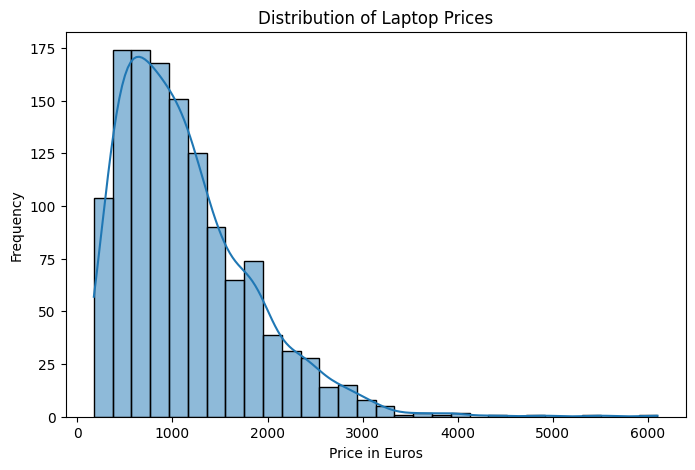

In [14]:
# Distribution of laptop prices
plt.figure(figsize=(8,5))

sns.histplot(df["Price_euros"], bins=30, kde=True)

plt.title("Distribution of Laptop Prices")
plt.xlabel("Price in Euros")
plt.ylabel("Frequency")

plt.show()

<h1>Laptop count by Company</h1>
A Count plot is used to display the number of laptops available from each company in the dataset.
This visualization helps identify:
<list><ul>
    <li>Which companies have the highest number of laptops</li>
    <li>Brand distribution within the dataset</li>
    <li>Most commonly represented laptop manufacturers</li></ul></list>

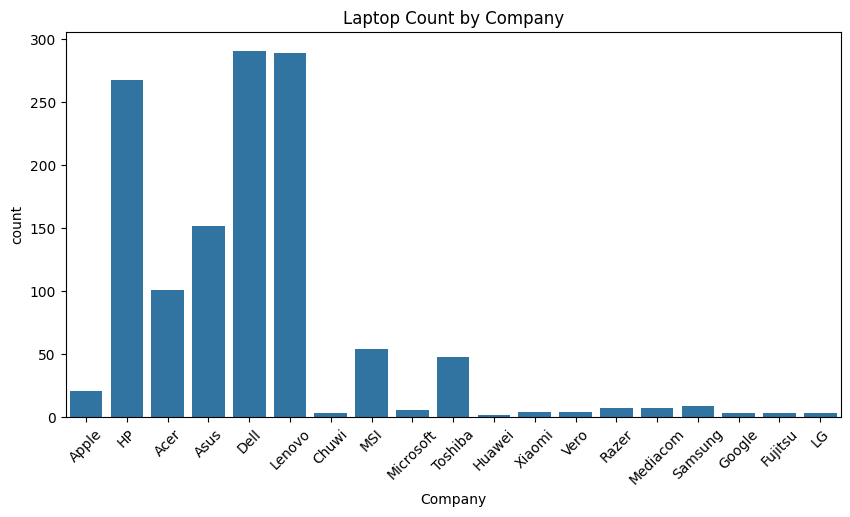

In [15]:
# Countplot for Company
plt.figure(figsize=(10,5))

sns.countplot(x=df["Company"])

plt.title("Laptop Count by Company")
plt.xticks(rotation=45)

plt.show()

<h1>Relationship between RAM and laptop price</h1>
A scatter plot is used to analyze the relationship betweeen RAM size and laptop price.<br>
The scatter plot helps identify:
<list><ul>
    <li>Price trends based on RAM size</li>
    <li>Data distribution</li>
    <li>Possible positive relationship between RAM and price</li></ul></list>

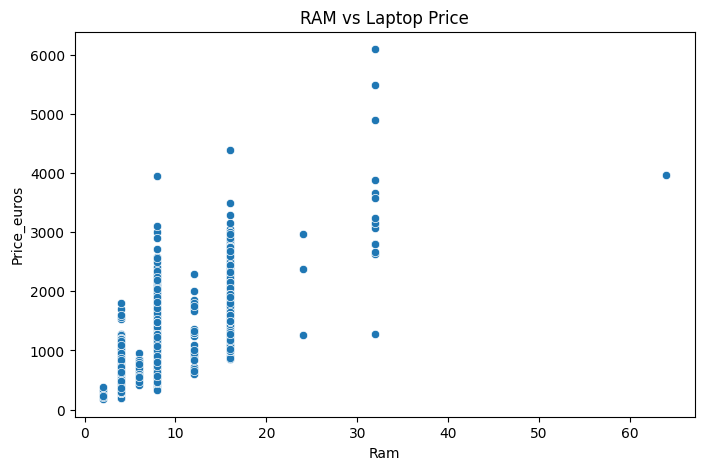

In [16]:
# RAM vs Price
plt.figure(figsize=(8,5))

sns.scatterplot(x=df["Ram"], y=df["Price_euros"])

plt.title("RAM vs Laptop Price")

plt.show()

<h1>Creating Dataset for Correlation Heatmap</h1>
A new dataframe is created using encoded features for correlation analysis.<br>
In this step:
<list><ul>
    <li>Encoded input features are copied</li>
    <li>Target variable(Price_euros) is added</li></ul></list>
This dataset is used to generate the correlation heatmap.

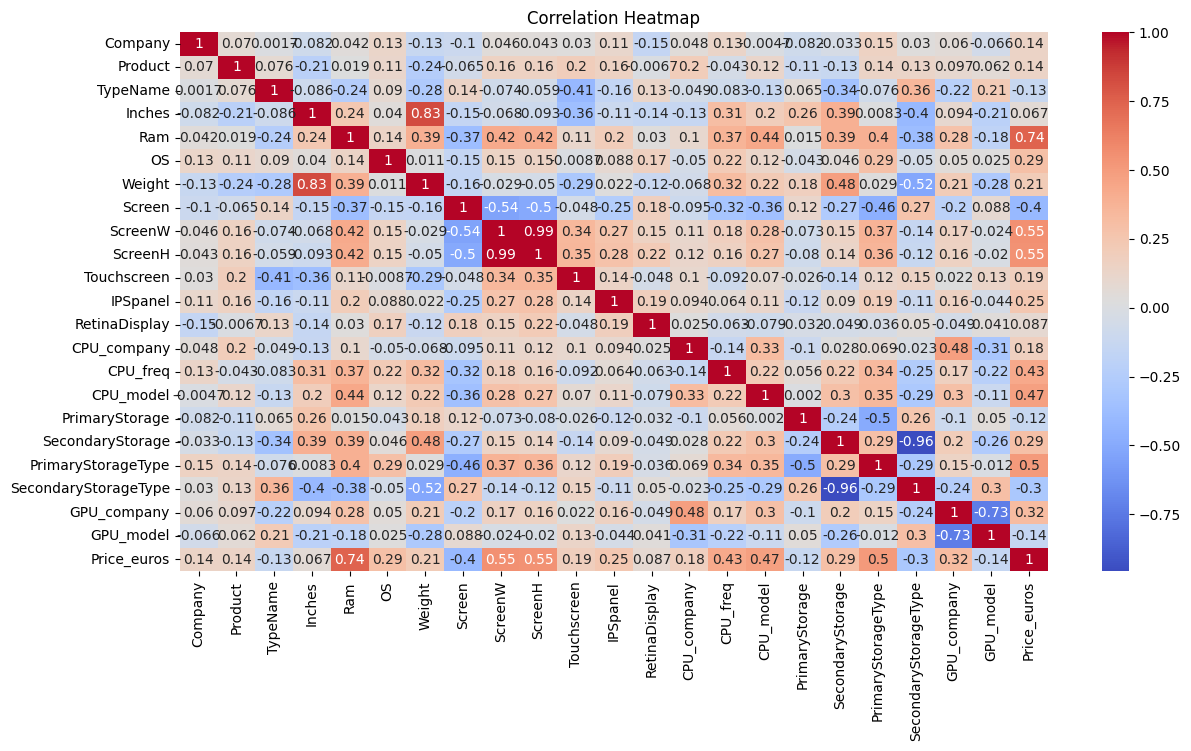

In [17]:
# Create dataframe for encoded features
encoded_df = x.copy()

# Add target variable
encoded_df["Price_euros"] = y
# Correlation heatmap
plt.figure(figsize=(14,7))

sns.heatmap(encoded_df.corr(), annot=True, cmap="coolwarm")

plt.title("Correlation Heatmap")

plt.show()

# Train_Test Split
The dataset is divided into training data and testing data.
<list><ul>
    <li>Training data is used to train the model</li>
    <li>Testing data is used to evaluate model performance</li></ul></list>
In this project:
<list><ul>
    <li>80% data is used for training</li>
    <li>20% data is used for testing</li></ul></list>

In [18]:
#spliting the data set into training set and test set
from sklearn.model_selection import train_test_split

x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=0)

In [19]:
# Display shapes
print("X_train Shape:", x_train.shape)
print("X_test Shape:", x_test.shape)

print("y_train Shape:", y_train.shape)
print("y_test Shape:", y_test.shape)

X_train Shape: (1020, 22)
X_test Shape: (255, 22)
y_train Shape: (1020,)
y_test Shape: (255,)


# Model development using Multiple Linear Regression
Multiple Linear Regression is used to predict laptop prices using multiple input features.
In this step:
<list><ul>
    <li>The linear regression model is created.</li>
    <li>The model is trained using training data</li></ul></list>
The model learns the relationship between laptop specifications and prices.

In [20]:
#training the model on model set
from sklearn.linear_model import LinearRegression
reg=LinearRegression()
reg.fit(x_train,y_train)


,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


# Model Prediction
After training the model,Predictions are generated using testing data.<br><br>
The model predicts laptop prices based on the learned patterns from the training dataset.

In [21]:
#predecting test result
y_pred_test=reg.predict(x_test)

# Actual and Predicted Results
A new dataframe is created to compare actual laptop prices with predicted preices.
<br>
In the table:
<list><ul>
    <li>Actual price represents the real laptop price</li>
    <li>Predicted price represents the model predicted value</li></ul></list>
This comparsion helps evaluate model predition performance

In [22]:
results=pd.DataFrame({
    "Actual Price":y_test,
    "Predicted Price":y_pred_test
})
results.head(10)

,Actual Price,Predicted Price
699,689.0,749.127874
649,1584.0,1541.988568
310,999.0,1175.918375
186,2397.0,2499.513708
184,1199.0,1044.299621
55,767.8,945.261851
871,479.0,432.529985
741,665.0,863.279971
364,499.0,852.898536
422,1427.0,1405.609535


# Actual VS Predicted Prices Graph
A scatter plot is used to compare actual laptop prices with predicted laptop prices.

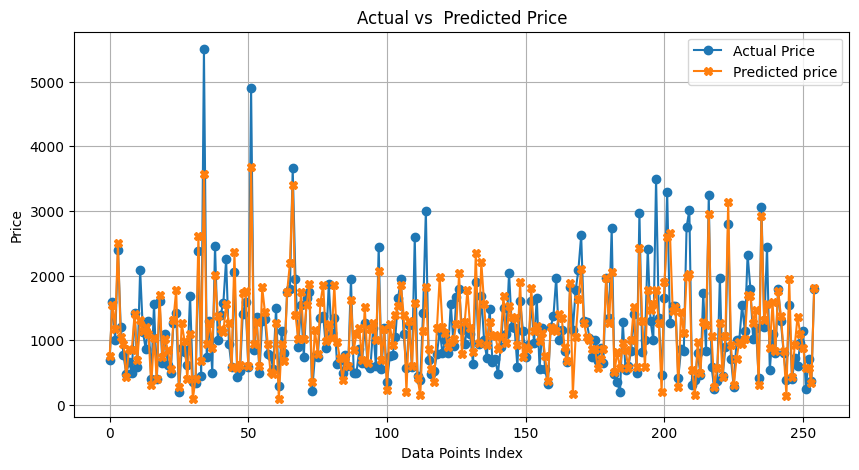

In [24]:
plt.figure(figsize=(10,5))
plt.plot(range(len(y_test)),y_test,label="Actual Price",marker = "o")
plt.plot(range(len(y_pred_test)),y_pred_test,label="Predicted price",marker = "X")


plt.xlabel("Data Points Index")
plt.ylabel("Price")
plt.title("Actual vs  Predicted Price")
plt.legend()
plt.grid(True)
plt.show()

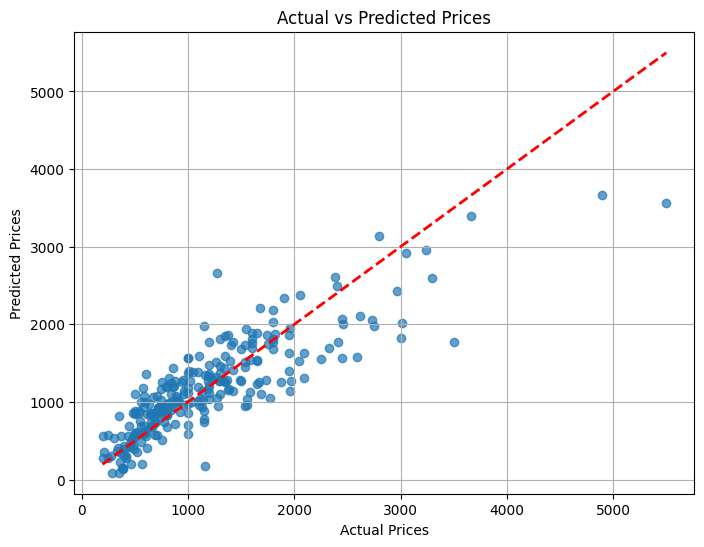

In [34]:
plt.figure(figsize=(8,6))

plt.scatter(y_test,y_pred_test,alpha=0.7)
plt.plot(
    [y_test.min(),y_test.max()],
    [y_test.min(),y_test.max()],
    'r--',
    linewidth=2
)

plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")

plt.title("Actual vs Predicted Prices")
plt.grid(True)
plt.show()

# Model Evaluation Metrics
Evalution metrices are used to measure the performance of the regression model.
<br>
The following are calculated:
<list><ul>
    <li>Mean Absolute Error(MAE) : <br> Measures the average prediction error.</li>
    <li>Mean Squared Error(MSE) : <br> Meaures the average squared prediction error. </li>
    <li>Median Absolute Error : <br>  Meaures the Median of all absolute error. </li>
    <li>Explained Variance Score : <br> Shows how well the model explains the variation in the model.</li>
    <li>R2 Score : <br> Measures the overall </li></ul></list>

In [33]:
import sklearn.metrics as sm
print("Mean absolute error =", round(sm.mean_absolute_error(y_test, y_pred_test), 2)) 
print("Mean squared error =", round(sm.mean_squared_error(y_test, y_pred_test), 2)) 

print("Median absolute error =", round(sm.median_absolute_error(y_test, y_pred_test), 2))
print("Explain variance score =", round(sm.explained_variance_score(y_test, y_pred_test), 2))
print("R2 score =", round(sm.r2_score(y_test, y_pred_test)))

Mean absolute error = 279.48
Mean squared error = 153513.06
Median absolute error = 201.75
Explain variance score = 0.74
R2 score = 1


## For regression models:

#### Lower MAE = Good
#### Lower MSE = Good
#### Lower Median AE = Good
#### Higher Explained Variance = Good
#### Higher R² = Good 

# Conclusion
In this project, Multiple Linear Regression was successfully used to predict laptop prices based on different laptop specifications.<br><br>
The dataset was preprocessed by cleaning data, selecting important features and encoding categorical variables using LabelEncoder.
<br><br>
Exploratory Data Analysis and correalation analysis were performed to better understand the dataset and relationships between variables.
<br>
The model wea trained and tested using training and testing dataset.Evalution metrics such as MAE,MSE,Median absolute error,Explain variance score,R2 score were used to measure model performance. <br><br>The results showed that the model was able to predict laptop prices with good accuracy.
<br><br>
Overall, this project demonstrated how supervised machine learning and Multiple Linear Regression can be used effectively for price prediction problems.